In [1]:
#This notebook determines correlation function estimates for a lattice-based ABM output. 
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import pdb
from scipy import integrate
import matplotlib as mpl
from scipy import interpolate
import time

from ABM_package import *
from ../EQL/PDE_FIND3 import * 
from ../EQL/model_selection_IP3 import *
import time, glob
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('png', 'pdf')
import os


#increase font size throughout
font = {'size'   : 25}
plt.rc('font', **font)

In [2]:
rp = 0.25
rd = 0.125
rm = 1.0
f= 1/2
den0 = .25

A_out, t_out, plot_list, interp_profiles = BDM_ABM(rp,rd,rm,f,den0, T_end=50.0)

Running ABM: 100%|███████████████████████████████| 50/50 [44:46<00:00, 53.73s/it]


In [ ]:
#ABM Attributes
n = 120 #length of lattice (nxn)
phenotypes = 1 #number of different agent types in simulation

#load ABM data
#upload some saved data here, save grid snapshots at plot_list and time array as t_out

In [3]:
#calculate correlation values at each recorded plot list. compute_F is a function defined in correlation_package.py. It utilizes the function count_occupied_pairs, which counts the occupied pairs of each combination of pairs. 
F_values = np.array([compute_F(A) for A in plot_list])

In [4]:
#preprocess F_values in order to visualize across non-dimensional ABM time 
num_snapshots = len(plot_list)
T_final = t_out[-1]
snapshot_times = np.linspace(0, T_final, num_snapshots)

F_out = interpolate.interp1d(snapshot_times, F_values, kind='linear')(t_out)

#calulate output derivitives
dF_dt = np.gradient(F_out, t_out)

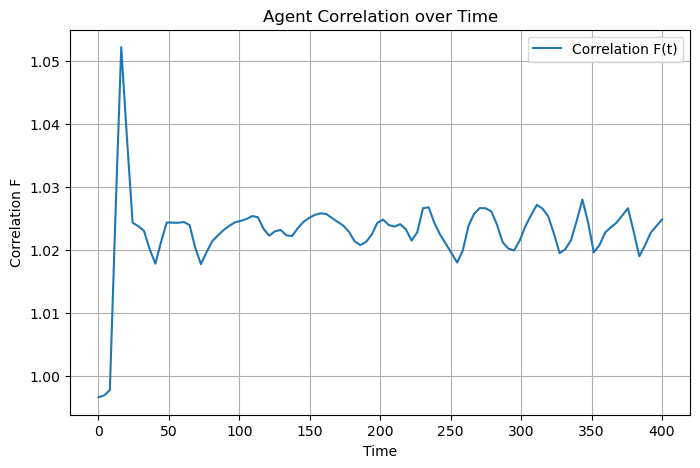

In [5]:
#plot correlation vs time
plt.figure(figsize=(8,5))
plt.plot(t_out, F_out, label='Correlation F(t)', color='tab:blue')
plt.xlabel('Time')
plt.ylabel('Correlation F')
plt.title('Agent Correlation over Time')
plt.grid(True)
plt.legend()
plt.show()


In [6]:
F_ss = F_out.mean()  # average 
print("average correlation", F_ss)

average correlation 1.0229275775316862


In [7]:
#equation learning
#initialize library of potential RHS terms (polynomials)
Theta = F_out
description = ['C^1']

#up to what order polynomials do we want?
deg = 2

for i in np.arange(2,deg+1):
    Theta = np.hstack([Theta,F_out**i])
    description.append('C^'+str(i))
    
print("Library terms are ")
print(description)
print("")
#perform linear regression
xi = np.linalg.lstsq(Theta,dF_dt,rcond=-1)[0]
print("Learned equation from regression is:")
print(print_pde(xi,description,n=5,ut="dF/dt"))


#Simulate the learned equation and compare to ABM output
RHS = learned_RHS_ODE
u_sim = ODE_sim(xi,RHS,t_out,F_out[0],description=description,deg=deg)

plt.figure(figsize=(9,7))
plt.plot(t_out,u_sim.T,'r--',linewidth=3,label='Learned model')
plt.plot(t_out[::4],F_out[::4],'b.',markersize=20,label='ABM data')
plt.xticks([])
plt.yticks([])
plt.title("Inferred model with regression")
plt.xlabel('Time (T)')
plt.ylabel("Correlation")

#plt.savefig("figures/ABM_tutorial_3.pdf",format="pdf")

Library terms are 
['C^1', 'C^2']



LinAlgError: 1-dimensional array given. Array must be two-dimensional